In [13]:
# Local steps to run in pycharm
# conda activate sage
# jupyter lab --no-browser --port=8888
# configure external server with the token
# sagemath (10.7)

from sage.all import *
from sage.plot.plot import graphics_array
from itertools import combinations
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white',
})

def graph_square(H):
    G = Graph()
    G.add_vertices(H.vertices())
    for u in H.vertices():
        for v in H.vertices():
            if u < v and H.distance(u,v) <= 2:
                G.add_edge(u,v)
    return G

def is_square_root(G, H):
    return graph_square(H) == G

def find_square_root(G):
    V = list(G.vertices())
    n = len(V)
    pairs = list(combinations(range(n), 2))

    total = 1 << len(pairs)
    for mask in range(total):
        H = Graph()
        H.add_vertices(V)
        for bit, (i, j) in enumerate(pairs):
            if (mask >> bit) & 1:
                H.add_edge(V[i], V[j])
        if is_square_root(G, H):
            return H
    return None

In [14]:
# Efficient find_square_root function

def violates_partial(G, H):
    for u, v in combinations(H.vertices(), 2):
        try:
            d = H.distance(u, v)
        except (ValueError, RuntimeError):
            continue

        if H.has_edge(u, v) and not G.has_edge(u, v):
            return True
        if d <= 2 and not G.has_edge(u, v):
            return True
    return False

def find_square_root(G):
    V = list(G.vertices())
    pairs = list(combinations(V, 2))
    H = Graph()
    H.add_vertices(V)

    def backtrack(idx):
        if idx == len(pairs):
            return H.copy() if is_square_root(G, H) else None

        u, v = pairs[idx]

        H.add_edge(u, v)
        if not violates_partial(G, H):
            result = backtrack(idx + 1)
            if result:
                return result
        H.delete_edge(u, v)

        if not violates_partial(G, H):
            result = backtrack(idx + 1)
            if result:
                return result

        return None

    return backtrack(0)


def find_all_square_roots(G):

    V = list(G.vertices())
    n = len(V)

    edges_G = set(tuple(sorted(e)) for e in G.edges(labels=False))

    from itertools import combinations
    all_edges = list(combinations(V,2))

    labeled_count = 0
    canonical_roots = {}

    def backtrack(idx, current_edges):

        nonlocal labeled_count

        if idx == len(all_edges):

            H = Graph()
            H.add_vertices(V)
            H.add_edges(current_edges)

            H2 = graph_square(H)
            edges_H2 = set(tuple(sorted(e)) for e in H2.edges(labels=False))

            if edges_H2 == edges_G:

                labeled_count += 1

                canon = H.canonical_label()
                key = canon.graph6_string()

                if key not in canonical_roots:
                    canonical_roots[key] = H.copy()

            return


        u,v = all_edges[idx]

        new_edges = current_edges + [(u,v)]

        H_partial = Graph()
        H_partial.add_vertices(V)
        H_partial.add_edges(new_edges)

        H2 = graph_square(H_partial)

        valid = True
        for e in H2.edges(labels=False):
            if tuple(sorted(e)) not in edges_G:
                valid = False
                break

        if valid:
            backtrack(idx+1,new_edges)

        backtrack(idx+1,current_edges)

    backtrack(0,[])

    return {
        "labeled": labeled_count,
        "non_isomorphic": list(canonical_roots.values())
    }

# LP with max objective function
def max_linear_program(G):
    m = MixedIntegerLinearProgram(solver = 'GLPK', maximization=False)
    m.solver_parameter("simplex_or_intopt", "intopt_only")

    x = m.new_variable(real=True, nonnegative=True)
    y = m.new_variable(real=True, nonnegative=True)
    z = m.new_variable(real=True, nonnegative=True)

    A_G = G.adjacency_matrix()
    n = A_G.nrows()
    M = n**2

    # Indicator argument
    for i in range(n):
        for j in range(n):
            if i == j:
                m.add_constraint(z[i,j] - (sum(y[i,k,j] for k in range(n)) - sum(x[i,k] for k in range(n)) + x[i,j]) == 0)
            else:
                m.add_constraint(z[i,j] - (sum(y[i,k,j] for k in range(n)) + x[i,j]) == 0)

    # Indicator function
    for i in range(n):
        for j in range(n):
            m.add_constraint(z[i,j] - M * A_G[i][j] <= 0)
            m.add_constraint(-z[i,j] + A_G[i][j] <= 0)

    # Product
    for i in range(n):
        for j in range(n):
            for k in range(n):
                m.add_constraint(y[i,k,j] - x[i,k] <= 0)
                m.add_constraint(y[i,k,j] - x[k,j] <= 0)
                m.add_constraint(- y[i,k,j] + x[i,k] + x[k,j] - 1 <= 0)

    # Symmetry
    for i in range(n):
        for j in range(n):
            m.add_constraint(x[i,j] == x[j,i])

    # Diagonal
    for i in range(n):
        m.add_constraint(x[i,i] == 0)

    # Variables
    for i in range(n):
        for j in range(n):
            m.add_constraint(x[i,j] - 1 <= 0)
            for k in range(n):
                m.add_constraint(y[i,k,j] - 1 <= 0)

    m.set_objective(- m.sum(x[i,j] for i in range(n) for j in range(n)))
    return m, x

In [15]:
from collections import defaultdict

def two_edge_triangles_from_edges(G):
    A = G.adjacency_matrix()
    n = G.num_verts()
    triangles = set()
    for u in range(n):
        for v in range(u + 1, n):
            if not A[u][v]:
                continue
            for w in range(n):
                if w == u or w == v:
                    continue
                if A[u][w] + A[v][w] == 1:
                    triangles.add(tuple(sorted((u, v, w))))
    return sorted(triangles)

def present_edges(i, j, k, G):
    A = G.adjacency_matrix()
    edges = []
    if A[i][j]:
        edges.append((i, j))
    if A[i][k]:
        edges.append((i, k))
    if A[j][k]:
        edges.append((j, k))
    return edges

def is_fixed(value, tol=1e-8):
    return abs(value) < tol or abs(value - 1) < tol

def find_consistent_inconsistent_groups(G, solution=None):
    triangles = two_edge_triangles_from_edges(G)
    H = Graph()
    for tri in triangles:
        e1, e2 = present_edges(*tri, G)
        if solution is not None:
            if is_fixed(solution[e1]):
                continue
            if is_fixed(solution[e2]):
                continue
        H.add_vertex(e1)
        H.add_vertex(e2)
        H.add_edge(e1, e2)
    consistent_groups = []
    inconsistent_groups = []
    for component in H.connected_components():
        C = H.subgraph(component)
        if C.num_verts() < 3:
            continue
        if C.is_bipartite():
            part0, part1 = C.bipartite_sets()
            consistent_groups.append({
                "edges": sorted(component),
                "part0": sorted(part0),
                "part1": sorted(part1),
            })
        else:
            inconsistent_groups.append({
                "edges": sorted(component),
            })
    return consistent_groups, inconsistent_groups

def edge_enforcement(G):
    consistent_groups, inconsistent_groups = find_consistent_inconsistent_groups(G)
    assignment = {}
    consistent_variables = []
    inconsistent_variables = []
    next_var = 0
    # Consistent groups
    for group in consistent_groups:
        a = var(f"a{next_var}")
        next_var += 1
        consistent_variables.append(a)
        for edge in group["part0"]:
            assignment[edge] = a
        for edge in group["part1"]:
            assignment[edge] = 1 - a
    # Inconsistent groups
    for group in inconsistent_groups:
        b = var(f"b{next_var}")
        next_var += 1
        inconsistent_variables.append(b)
        for edge in group["edges"]:
            assignment[edge] = b

    return assignment, consistent_variables, inconsistent_variables

def edge_enforcement_linear_equations(G):
    assignment, consistent_vars, inconsistent_vars = edge_enforcement(G)
    return assignment

def max_edge_enforcement_no_fixing_linear_program(G, verbose=False):

    m, x = max_linear_program(G)

    triangles = two_edge_triangles_from_edges(G)
    assignment, consistent_vars, inconsistent_vars = edge_enforcement(G)

    variables = consistent_vars + inconsistent_vars

    if verbose:
        print("=" * 60)
        print("Edge Enforcement")
        print("=" * 60)

        print(f"Two-edge triangles ({len(triangles)}):")
        for t in triangles:
            print(f"  {t}")

        print(f"\nConsistent variables ({len(consistent_vars)}):")
        for a in consistent_vars:
            print(f"  {a}")

        print(f"\nInconsistent variables ({len(inconsistent_vars)}):")
        for b in inconsistent_vars:
            print(f"  {b}")

        print("\nEdge assignments:")
        for edge in sorted(assignment):
            print(f"  {edge} -> {assignment[edge]}")

        print("=" * 60)

    var_index = {v: i for i, v in enumerate(variables)}

    group_lp = m.new_variable(real=True)

    for i in range(len(variables)):
        m.add_constraint(group_lp[i] >= 0)
        m.add_constraint(group_lp[i] <= 1)

    # for b in inconsistent_vars:
    #     idx = var_index[b]
    #     m.add_constraint(group_lp[idx] == QQ(1)/2)

    for edge, expr in assignment.items():
        if expr.operator() is None:
            idx = var_index[expr]
            m.add_constraint(x[edge] == group_lp[idx])

        else:
            v = expr.variables()[0]
            idx = var_index[v]
            m.add_constraint(x[edge] == 1 - group_lp[idx])

    return m, x, group_lp, variables, assignment


def choose_inconsistent_star(G, inconsistent_groups):
    for group in inconsistent_groups:
        stars = defaultdict(list)
        for u, v in group["edges"]:
            stars[u].append((u,v))
            stars[v].append((u,v))

        centre = max(stars, key=lambda x: len(stars[x]))

        return {
            "centre": centre,
            "edges": stars[centre]
        }
    return None

def choose_star_edge(star):
    return sorted(star["edges"])[0]

def choose_consistent_group(consistent_groups):
    if not consistent_groups:
        return None
    return sorted(consistent_groups, key=lambda g: sorted(g))[0]

def choose_group_symbol(group):
    return min(group["edges"])

def choose_branch_on_group(assignment, symbol):
    value = assignment[symbol]
    if value >= 0.5:
        return 1
    else:
        return 0

def choose_branch(assignment, edge):
    return int(assignment[edge] >= 0.5)

def max_edge_enforcement_fixing_linear_program(G):
    m, x, a_lp, variables, assignment = max_edge_enforcement_no_fixing_linear_program(G)
    while True:
        m.solve()
        assignment = m.get_values(x)

        consistent, inconsistent = find_consistent_inconsistent_groups(G, assignment)

        if inconsistent:

            star = choose_inconsistent_star(G, inconsistent)
            edge = choose_star_edge(star)

            value = choose_branch(assignment, edge)

            m.add_constraint(x[edge] == value)

            continue

        group = choose_consistent_group(consistent)

        if group is None:
            break

        symbol = choose_group_symbol(group)

        value = choose_branch_on_group(assignment, symbol)

        m.add_constraint(x[symbol] == value)
    return m, x

In [16]:
# Generate all possible graph squares/roots for given n
import os
import itertools
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from sage.numerical.mip import MIPSolverException
from sage.graphs.graph_generators import graphs as graph_gens

n = 7
ncpus = 12
dir = f"max_edge_enforcement_no_fixing_graph_output"
output_dir = os.path.join(dir, f"n={n}")
output_pdf = os.path.join(output_dir, f"graph_results_n={n}.pdf")
comparison_pdf = os.path.join(output_dir, f"graph_comparison_n={n}.pdf")
summary_file = os.path.join(output_dir, f"graph_summary_n={n}.txt")

os.makedirs(output_dir, exist_ok=True)
os.makedirs(dir, exist_ok=True)

def error_plot(message):
    g = Graphics()
    g += text(message, (0, 0), fontsize=14, color="red", horizontal_alignment='center')
    g.axes(False)
    return g

def is_claw_free_graph(G):
    for v in G.vertices():
        N = G.neighbors(v)
        if len(N) < 3:
            continue
        for a in range(len(N)):
            for b in range(a+1, len(N)):
                for c in range(b+1, len(N)):
                    u1, u2, u3 = N[a], N[b], N[c]
                    if (not G.has_edge(u1, u2) and
                        not G.has_edge(u1, u3) and
                        not G.has_edge(u2, u3)):
                        return False
    return True

def is_dismantlable_graph(G):
    G_1 = G.copy()

    while G_1.order() > 1:
        found = False

        for v in G_1.vertices():
            Nv = set(G_1.neighbors(v)) | {v}

            for u in G_1.vertices():
                if u == v:
                    continue

                Nu = set(G_1.neighbors(u)) | {u}

                if Nv.issubset(Nu):
                    G_1.delete_vertex(v)
                    found = True
                    break

            if found:
                break

        if not found:
            return False

    return True

def process_graph(idx, G, label):
    G.relabel(range(G.order()))
    n = G.order()

    A_H = None
    sol_H = None
    H = None
    lp_status = "unknown"
    has_root = False
    edges_H = None
    is_noninteger = False

    try:
        # m, x = max_edge_enforcement_fixing_linear_program(G)
        m, x, a_lp, variables, assignment = max_edge_enforcement_no_fixing_linear_program(G)
        m.solve()
        solution_x = m.get_values(x)
        A_H = matrix([[solution_x[i, j] for j in range(n)] for i in range(n)])
        sol_H = Graph(A_H, weighted=True)
        for (u, v, w) in sol_H.edges():
            sol_H.set_edge_label(u, v, round(w, 3))
        p1 = sol_H.plot(edge_labels=True, title='Weighted LP H')
        lp_status = "feasible"

        if any(abs(A_H[i, j] - round(A_H[i, j])) > 1e-6 for i in range(n) for j in range(n)):
            is_noninteger = True

    except MIPSolverException:
        sol_H = None
        p1 = error_plot("LP infeasible")
        lp_status = "infeasible"

    root_info = find_all_square_roots(G)
    num_total_roots = root_info.get("labeled", 0)
    unique_roots = root_info.get("non_isomorphic", [])
    num_unique_roots = len(unique_roots)
    has_root = num_total_roots > 0
    H = unique_roots[0] if num_unique_roots > 0 else None

    root_properties = {
        "is_tree": None,
        "is_bipartite": None,
        "is_proper_interval": None,
        "is_girth_more_than_six": None,
        "is_block": None,
        "is_comparability": None,
        "is_dismantlable": None
    }

    if H is None:
        p2 = error_plot("No feasible H")
        has_root = False
        edges_H = None
    else:
        p2 = H.plot(title='Feasible H')
        has_root = True
        edges_H = H.size()

        root_properties["is_tree"] = H.is_tree()
        root_properties["is_bipartite"] = H.is_bipartite()
        is_interval = H.is_interval()
        is_claw_free = is_claw_free_graph(H)
        root_properties["is_proper_interval"] = is_interval and is_claw_free

        if H.is_tree():
            root_properties["is_girth_more_than_six"] = True
        else:
            g = H.girth()
            root_properties["is_girth_more_than_six"] = (g is not None and g > 6)

        root_properties["is_block"] = H.is_block_graph()
        root_properties["is_comparability"] = H.is_comparability()
        root_properties["is_dismantlable"] = is_dismantlable_graph(H)

    p3 = G.plot(title=f"{label} G (#{idx})")

    summary = {
        "index": idx,
        "edges_G": G.size(),
        "vertices_G": n,
        "lp_status": lp_status,
        "has_root": has_root,
        "edges_H": H.size() if H else None,
        "is_noninteger": is_noninteger,
        "total_roots": num_total_roots,
        "unique_roots": num_unique_roots,
        **root_properties
    }

    is_mismatch = (is_noninteger or (lp_status == "feasible" and H is None))

    if is_mismatch:
        if sol_H is not None:
            p_left = sol_H.plot(edge_labels=True, title="Weighted LP H")
        else:
            p_left = error_plot("No LP solution")

        if H is not None:
            p_mid = H.plot(title="Feasible H")
        else:
            p_mid = error_plot("No discrete H")

        p_right = G.plot(title="Original G")
        comparison = graphics_array([p_left, p_mid, p_right])
    else:
        comparison = None

    return (p1, p2, p3), summary, comparison, is_mismatch

def analyze_isomorphic_lp(G):
    n = G.order()
    perms = itertools.permutations(range(n))

    integer_count = 0
    fractional_count = 0
    infeasible_count = 0

    for perm in perms:
        Gp = G.relabel(dict(zip(range(n), perm)), inplace=False)

        try:
            # m, x = max_edge_enforcement_fixing_linear_program(Gp)
            m, x, a_lp, variables, assignment = max_edge_enforcement_no_fixing_linear_program(Gp)
            m.solve()
            sol = m.get_values(x)

            A = matrix([[sol[i, j] for j in range(n)] for i in range(n)])

            is_fractional = any(
                abs(A[i, j] - round(A[i, j])) > 1e-6
                for i in range(n)
                for j in range(n)
            )

            if is_fractional:
                fractional_count += 1
            else:
                integer_count += 1

        except MIPSolverException:
            infeasible_count += 1

    return {
        "total_perms": factorial(n),
        "integer": integer_count,
        "fractional": fractional_count,
        "infeasible": infeasible_count
    }

def run_task(idx, G, label):
    return process_graph(idx, G, label)

tasks = [(i, Graph(G0)) for i, G0 in enumerate(graph_gens.nauty_geng(str(n)))]

results = []
mismatch_results = []

for idx, G in tasks:
    plot_G, summary_G, comp_G, mismatch_G = run_task(idx, G, label="Original")
    if summary_G["is_noninteger"] and summary_G["has_root"]:
        iso_diag = analyze_isomorphic_lp(G)
        summary_G["iso_analysis"] = iso_diag

    if mismatch_G and comp_G is not None:
        mismatch_results.append((comp_G, summary_G))

    (p1, p2, p3) = plot_G

    combined = graphics_array([[p1, p2, p3]])
    results.append((combined, summary_G))

    print(
        f"✅ Graph {summary_G['index']:>4}: "
        f"LP={summary_G['lp_status']} "
        f"Root={summary_G['has_root']} "
        f"{'(⚠️ mismatch)' if mismatch_G else ''}"
    )

with open(summary_file, "w") as f:
    header = (
        f"{'Graph':>5} | {'Verts':>5} | {'Edges(G)':>8} | "
        f"{'Roots':>7} | {'NonIso':>7} | "
        f"{'Edges(H)':>8} | {'LP':>10} | {'Root':>5} | "
        f"{'NonInt':>7} | "
        f"{'Tree':>5} | {'Bip':>5} | {'PropInt':>7} | "
        f"{'Girth>6':>8} | {'Block':>5} | {'Comparability':>5} | "
        f"{'Dismantlable':>5}\n"
    )
    f.write(header)
    f.write("-" * len(header) + "\n")

    for _, s in results:
        f.write(
            f"{s['index']:>5} | "
            f"{s['vertices_G']:>5} | "
            f"{s['edges_G']:>8} | "
            f"{s['total_roots']:>7} | "
            f"{s['unique_roots']:>7} | "
            f"{str(s['edges_H']) if s['edges_H'] is not None else 'NA':>8} | "
            f"{s['lp_status']:<10} | "
            f"{'Yes' if s['has_root'] else 'No':>5} | "
            f"{'Yes' if s['is_noninteger'] else 'No':>7} | "
            f"{'Yes' if s['is_tree'] else 'No':>5} | "
            f"{'Yes' if s['is_bipartite'] else 'No':>5} | "
            f"{'Yes' if s['is_proper_interval'] else 'No':>7} | "
            f"{'Yes' if s['is_girth_more_than_six'] else 'No':>8} | "
            f"{'Yes' if s['is_block'] else 'No':>5} | "
            f"{'Yes' if s['is_comparability'] else 'No':>5} |"
            f"{'Yes' if s['is_dismantlable'] else 'No':>5}\n"
        )

        if "iso_analysis" in s:

            iso = s["iso_analysis"]

            f.write(
                f"      ISO CHECK → perms={iso['total_perms']} | "
                f"integer={iso['integer']} | "
                f"fractional={iso['fractional']} | "
                f"infeasible={iso['infeasible']}\n"
            )

        f.write("-" * len(header) + "\n")

print(f"📝 Summary written to {summary_file}")

with PdfPages(output_pdf) as pdf:
    for p, sG in results:
        fig = p.matplotlib(figsize=(12, 4))
        pdf.savefig(fig)
        plt.close(fig)
print(f"\n✅ Combined {len(results)} graphs into {output_pdf}")


if mismatch_results:
    with PdfPages(comparison_pdf) as pdf:
        for comp, s in mismatch_results:

            fig = comp.matplotlib(figsize=(12, 4))

            plt.suptitle(
                f"Graph {s['index']} — "
                f"LP={s['lp_status']} | "
                f"Root={s['has_root']} | "
                f"{'Non-integer LP' if s['is_noninteger'] else ''}"
            )

            pdf.savefig(fig)
            plt.close(fig)

    print(f"⚠️ Comparison mismatches saved to {comparison_pdf}")

✅ Graph    0: LP=feasible Root=True 
✅ Graph    1: LP=feasible Root=True 
✅ Graph    2: LP=infeasible Root=False 
✅ Graph    3: LP=infeasible Root=False 
✅ Graph    4: LP=infeasible Root=False 
✅ Graph    5: LP=infeasible Root=False 
✅ Graph    6: LP=infeasible Root=False 
✅ Graph    7: LP=feasible Root=True 
✅ Graph    8: LP=infeasible Root=False 
✅ Graph    9: LP=infeasible Root=False 
✅ Graph   10: LP=feasible Root=True 
✅ Graph   11: LP=infeasible Root=False 
✅ Graph   12: LP=infeasible Root=False 
✅ Graph   13: LP=infeasible Root=False 
✅ Graph   14: LP=infeasible Root=False 
✅ Graph   15: LP=infeasible Root=False 
✅ Graph   16: LP=infeasible Root=False 
✅ Graph   17: LP=infeasible Root=False 
✅ Graph   18: LP=infeasible Root=False 
✅ Graph   19: LP=infeasible Root=False 
✅ Graph   20: LP=infeasible Root=False 
✅ Graph   21: LP=infeasible Root=False 
✅ Graph   22: LP=infeasible Root=False 
✅ Graph   23: LP=infeasible Root=False 
✅ Graph   24: LP=infeasible Root=False 
✅ Graph   25

<Figure size 640x480 with 0 Axes>

In [17]:
n = 7
filename = f"max_edge_enforcement_no_fixing_graph_output/n={n}/graph_summary_n={n}.txt"

summary = {}
graph_info = {}
iso_effects = []
original_status = {}
current_graph = None
total_graphs = 0

with open(filename, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()

        if not line or line.startswith("-") or line.startswith("SUMMARY") or line.startswith("Graph"):
            continue

        if line.startswith("ISO CHECK"):
            if current_graph is None:
                continue

            parts = [p.strip() for p in line.replace("ISO CHECK →", "").split("|")]

            iso_data = {}
            for p in parts:
                key, value = p.split("=")
                iso_data[key.strip()] = int(value.strip())

            graph_info[current_graph]["ISO"] = iso_data
            continue

        parts = [p.strip() for p in line.split("|")]

        if len(parts) != 16:
            continue

        (
            graph,
            verts,
            edges_g,
            roots_total,
            roots_unique,
            edges_h,
            lp,
            root,
            nonint,
            tree,
            bip,
            propint,
            girth6,
            block,
            comparability,
            dismantlable
        ) = parts

        idx = int(graph)
        current_graph = idx

        total_graphs += 1

        roots_total = int(roots_total)
        roots_unique = int(roots_unique)

        H_exists = (root == "Yes")

        if lp == "infeasible":
            LP_type = "LP infeasible"
        elif nonint == "Yes":
            LP_type = "LP fractional"
        else:
            LP_type = "LP integer"

        key = (H_exists, LP_type)
        summary.setdefault(key, []).append(idx)

        graph_info[idx] = {
            "H_exists": H_exists,
            "LP_type": LP_type,
            "TotalRoots": roots_total,
            "NonIsoRoots": roots_unique,
            "Tree": tree,
            "Bip": bip,
            "PropInt": propint,
            "Girth>6": girth6,
            "Block": block,
            "Comparability": comparability,
            "Dismantlable": dismantlable
        }

for (H_exists, LP_type), graphs in sorted(summary.items()):
    print(
        f"H exists: {str(H_exists):<5} | "
        f"{LP_type:<15} → "
        f"{len(graphs)} graphs"
    )

properties = [
    ("Tree", "Tree"),
    ("Bip", "Bipartite"),
    ("PropInt", "Proper Interval"),
    ("Girth>6", "Girth > 6"),
    ("Block", "Block Graph"),
    ("Comparability", "Comparability"),
    ("Dismantlable", "Dismantlable")
]

for key, label in properties:

    H_true_yes = 0
    H_true_no = 0
    H_false_yes = 0
    H_false_no = 0

    for info in graph_info.values():

        if info["LP_type"] != "LP fractional":
            continue

        H = info["H_exists"]
        val = info[key]

        if H:
            if val == "Yes":
                H_true_yes += 1
            else:
                H_true_no += 1
        else:
            if val == "Yes":
                H_false_yes += 1
            else:
                H_false_no += 1

    print(f"\n{label} for fractional solutions")
    print(f"H=True  | {label}=Yes → {H_true_yes}")
    print(f"H=True  | {label}=No  → {H_true_no}")
    print(f"H=False | {label}=Yes → {H_false_yes}")
    print(f"H=False | {label}=No  → {H_false_no}")

print()

for idx in sorted(graph_info):

    info = graph_info[idx]

    if not (not info["LP_type"] == "LP integer" and info["H_exists"]):
        continue

    warning = (
        info["Tree"] == "No"
        and info["Bip"] == "No"
        and info["PropInt"] == "No"
        and info["Girth>6"] == "No"
        and info["Block"] == "No"
    )

    warn_symbol = " ⚠" if warning else ""

    print(f"Graph {idx}{warn_symbol}")

    print(
        f"  Original → "
        f"H exists: {info['H_exists']} | "
        f"{info['LP_type']}"
    )

    print(
        f"  Roots: {info['TotalRoots']} iso | "
        f"{info['NonIsoRoots']} non-iso"
    )

    print(
        f"  Properties: "
        f"Tree={info['Tree']} "
        f"Bip={info['Bip']} "
        f"PI={info['PropInt']} "
        f"Girth>6={info['Girth>6']} "
        f"Block={info['Block']} "
        f"Comparability={info['Comparability']} "
        f"Dismantlable={info['Dismantlable']}"
    )

    if "ISO" in info:
        iso = info["ISO"]
        print("  ISO permutations:", iso["perms"])
        print("     Integer:", iso["integer"])
        print("     Fractional:", iso["fractional"])
        print("     Infeasible:", iso["infeasible"])

    print()

H exists: False | LP fractional   → 200 graphs
H exists: False | LP infeasible   → 767 graphs
H exists: True  | LP fractional   → 52 graphs
H exists: True  | LP integer      → 25 graphs

Tree for fractional solutions
H=True  | Tree=Yes → 3
H=True  | Tree=No  → 49
H=False | Tree=Yes → 0
H=False | Tree=No  → 200

Bipartite for fractional solutions
H=True  | Bipartite=Yes → 13
H=True  | Bipartite=No  → 39
H=False | Bipartite=Yes → 0
H=False | Bipartite=No  → 200

Proper Interval for fractional solutions
H=True  | Proper Interval=Yes → 29
H=True  | Proper Interval=No  → 23
H=False | Proper Interval=Yes → 0
H=False | Proper Interval=No  → 200

Girth > 6 for fractional solutions
H=True  | Girth > 6=Yes → 8
H=True  | Girth > 6=No  → 44
H=False | Girth > 6=Yes → 0
H=False | Girth > 6=No  → 200

Block Graph for fractional solutions
H=True  | Block Graph=Yes → 12
H=True  | Block Graph=No  → 40
H=False | Block Graph=Yes → 0
H=False | Block Graph=No  → 200

Comparability for fractional solutions
H

Graph #142


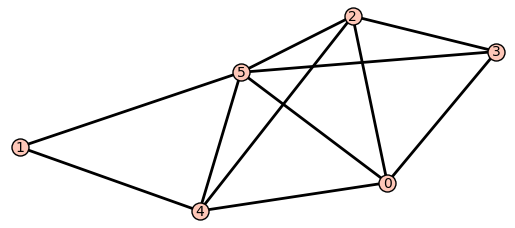

LP status: infeasible


In [18]:
%matplotlib inline

from sage.all import Graph, graphs
from sage.numerical.mip import MIPSolverException

def display_graph(idx=None, n=None, G=None):

    if G is None:
        if idx is None or n is None:
            raise ValueError("Provide either G or (idx, n).")

        for i, g in enumerate(graphs.nauty_geng(str(n))):
            if i == idx:
                G = Graph(g)
                break

        if G is None:
            print("Graph not found.")
            return
    else:
        G = Graph(G)

    G.relabel(range(G.order()), inplace=True)

    print("="*80)
    print(f"Graph #{idx}")
    print("="*80)

    display(
        G.plot(
            vertex_labels=True,
            vertex_size=150,
            edge_thickness=2,
            title="G"
        ).matplotlib()
    )

    try:
        m, x = max_edge_enforcement_fixing_linear_program(G)
        m.solve()

        sol = m.get_values(x)

        eps = 1e-8

        A = matrix(
            [
                [
                    0 if abs(sol[i,j]) < eps else round(sol[i,j], 3)
                    for j in range(G.order())
                ]
                for i in range(G.order())
            ]
        )


        fractional = any(
            abs(A[i, j] - round(A[i, j])) > 1e-6
            for i in range(G.order())
            for j in range(G.order())
        )

        lp_type = "fractional" if fractional else "integer"

        H_lp = Graph(A, weighted=True)

        for (u, v, w) in H_lp.edges():
            H_lp.set_edge_label(u, v, round(w, 3))

        print("LP status: feasible")
        print("LP type:", lp_type)
        display(
            H_lp.plot(
                vertex_labels=True,
                edge_labels=True,
                vertex_size=150,
                edge_thickness=2,
                title="H"
            ).matplotlib()
        )

    except MIPSolverException:

        print("LP status: infeasible")
        lp_type = "infeasible"


display_graph(142, 6)
# H = Graph()
# H.add_edges([
#     (0,1),(0,2),(0,3),
#     (1,2),(1,3),
#     (2,3)
# ])
# H.add_edges([
#     (0,4),
#     (1,5),
#     (2,6),
#     (3,7)
# ])
# G = graph_square(H)
# display_graph(G=G)